# Stock Direction Prediction
## Day 1 - Data Understanding and Exploratory Data Analysis

### Objective

The objective of this project is to predict whether the closing
price of a stock will increase or decrease on the next trading day.

This notebook performs:

1. Dataset loading
2. Dataset inspection
3. Data quality analysis
4. Missing-value analysis
5. Duplicate analysis
6. Statistical analysis
7. Stock-wise analysis
8. Return analysis
9. Correlation analysis
10. Exploratory visualizations

No machine learning model is trained in this notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [4]:
import os

raw_path = "../data/raw"

print(os.listdir(raw_path))

['daily_finbert_sentiment.csv', 'nifty50_historical_data.csv', 'nifty50_summary_statistics.csv', 'sp500_headlines_2008_2024.csv']


In [6]:
import os

print(os.getcwd())

c:\Users\Sampat\OneDrive\Desktop\NEW_STOCK\stock-direction-prediction\notebooks


In [8]:

sentiment_path = "../data/raw/daily_finbert_sentiment.csv"
stock_path = "../data/raw/nifty50_historical_data.csv"
summary_path = "../data/raw/nifty50_summary_statistics.csv"
news_path = "../data/raw/sp500_headlines_2008_2024.csv"

sentiment_df = pd.read_csv(sentiment_path)
stock_df = pd.read_csv(stock_path)
summary_df = pd.read_csv(summary_path)
news_df = pd.read_csv(news_path)

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [9]:
print("Stock Data Shape:", stock_df.shape)
print("Sentiment Data Shape:", sentiment_df.shape)
print("News Data Shape:", news_df.shape)
print("Company Summary Shape:", summary_df.shape)

Stock Data Shape: (287310, 25)
Sentiment Data Shape: (3507, 9)
News Data Shape: (19127, 3)
Company Summary Shape: (49, 18)


In [10]:
stock_df.head()

,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,Stock_Split,Daily_Return,Volatility_20D,MA_50,MA_200,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
0,1999-01-01 00:00:00+05:30,AXISBANK.NS,Axis Bank Ltd.,Financials,2.198795,2.212041,2.139190,2.165681,337500,0.0,NaN,NaN,NaN,NaN,NaN,4257978515456,16.260086,13.534726,NaN,2.055485,0.07,84.28,0.313,1378.70,978.05
1,1999-01-01 00:00:00+05:30,BPCL.NS,Bharat Petroleum Corporation Ltd.,Energy,3.059547,3.083643,3.035450,3.073874,324744,0.0,NaN,NaN,NaN,NaN,NaN,1581385383936,6.329224,7.975497,NaN,1.658039,4.80,57.59,0.981,388.15,234.01
2,1999-01-01 00:00:00+05:30,BRITANNIA.NS,Britannia Industries Ltd.,FMCG,40.944134,40.974527,40.775792,40.845936,42000,0.0,NaN,NaN,NaN,NaN,NaN,1411608608768,60.977005,48.923096,NaN,37.810410,1.28,96.11,0.572,6336.00,4506.00
3,1999-01-01 00:00:00+05:30,CIPLA.NS,Cipla Ltd.,Pharma,19.149712,19.580167,19.006226,19.426748,108750,0.0,NaN,NaN,NaN,NaN,NaN,1069501579264,23.529411,23.371544,NaN,3.248832,0.98,56.27,0.042,1673.00,1281.70
4,1999-01-01 00:00:00+05:30,DRREDDY.NS,Dr. Reddy's Laboratories Ltd.,Pharma,21.000834,21.293348,21.000834,21.185806,2324000,0.0,NaN,NaN,NaN,NaN,NaN,1014151315456,17.929054,22.147236,NaN,2.723533,0.66,67.94,0.315,1379.70,1020.00


In [11]:
sentiment_df.head()

,Date,News_Count,Avg_Sentiment,Positive_Sentiment,Negative_Sentiment,Neutral_Sentiment,Max_Sentiment,Min_Sentiment,Sentiment_Std
0,2008-01-02,3,-0.478792,0.084254,0.563047,0.352699,-0.069877,-0.950723,0.443791
1,2008-01-03,1,0.797434,0.861627,0.064193,0.074181,0.797434,0.797434,0.000000
2,2008-01-07,1,0.421510,0.586566,0.165056,0.248378,0.421510,0.421510,0.000000
3,2008-01-09,2,-0.375605,0.053437,0.429043,0.517520,0.068080,-0.819291,0.627466
4,2008-01-10,1,0.259897,0.542340,0.282442,0.175218,0.259897,0.259897,0.000000


In [12]:
news_df.head()

,Title,Date,CP
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16
2,2008 predictions for the S&P 500,2008-01-02,1447.16
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18


In [13]:
summary_df.head()

,Ticker,Company_Name,Sector,First_Date,Last_Date,Total_Trading_Days,Starting_Price,Ending_Price,Total_Return_%,Highest_Price,Lowest_Price,Avg_Daily_Volume,Total_Dividends_Paid,Number_of_Splits,Avg_Daily_Return_%,Volatility_%,Current_Market_Cap,Current_PE_Ratio
0,EICHERMOT.NS,Eicher Motors Ltd.,Automobile,1999-01-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,6767,0.712911,7122.500000,998972.801823,7613.500000,0.584353,5.260628e+05,271.600000,1,0.293300,11.334566,1953696317440,38.377605
1,BAJFINANCE.NS,Bajaj Finance Ltd.,Financials,2002-07-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,5856,0.392581,929.849976,236755.581063,1102.500000,0.266442,9.562993e+06,18.844086,2,2.002004,141.815279,5780268908544,31.541723
2,TITAN.NS,Titan Company Ltd.,Consumer Durables,1999-01-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,6770,3.933924,3977.399902,101005.148498,4312.100098,1.210438,3.647869e+06,72.700000,1,0.139343,2.741165,3528133705728,85.461970
3,SHREECEM.NS,Shree Cement Ltd.,Cement,2001-07-02 00:00:00+05:30,2026-01-30 00:00:00+05:30,6116,27.222359,26985.000000,99028.074440,32398.188356,18.588853,2.836315e+04,1081.500000,0,0.138320,2.263643,973638991872,56.497707
4,SUNPHARMA.NS,Sun Pharmaceutical Industries Ltd.,Pharma,1999-01-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,6770,1.718485,1595.300049,92731.744721,1942.212840,1.703690,3.132031e+06,89.000000,5,0.125672,2.227590,3827659177984,36.631460


In [14]:
print("Stock Columns:")
print(stock_df.columns.tolist())

print("\nSentiment Columns:")
print(sentiment_df.columns.tolist())

print("\nNews Columns:")
print(news_df.columns.tolist())

print("\nSummary Columns:")
print(summary_df.columns.tolist())

Stock Columns:
['Date', 'Ticker', 'Company_Name', 'Sector', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividend', 'Stock_Split', 'Daily_Return', 'Volatility_20D', 'MA_50', 'MA_200', 'Market_Cap', 'PE_Ratio', 'Forward_PE', 'PEG_Ratio', 'Price_to_Book', 'Dividend_Yield', 'EPS', 'Beta', '52Week_High', '52Week_Low']

Sentiment Columns:
['Date', 'News_Count', 'Avg_Sentiment', 'Positive_Sentiment', 'Negative_Sentiment', 'Neutral_Sentiment', 'Max_Sentiment', 'Min_Sentiment', 'Sentiment_Std']

News Columns:
['Title', 'Date', 'CP']

Summary Columns:
['Ticker', 'Company_Name', 'Sector', 'First_Date', 'Last_Date', 'Total_Trading_Days', 'Starting_Price', 'Ending_Price', 'Total_Return_%', 'Highest_Price', 'Lowest_Price', 'Avg_Daily_Volume', 'Total_Dividends_Paid', 'Number_of_Splits', 'Avg_Daily_Return_%', 'Volatility_%', 'Current_Market_Cap', 'Current_PE_Ratio']


In [15]:
stock_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 287310 entries, 0 to 287309
Data columns (total 25 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Date            287310 non-null  str    
 1   Ticker          287310 non-null  str    
 2   Company_Name    287310 non-null  str    
 3   Sector          287310 non-null  str    
 4   Open            287310 non-null  float64
 5   High            287310 non-null  float64
 6   Low             287310 non-null  float64
 7   Close           287310 non-null  float64
 8   Volume          287310 non-null  int64  
 9   Dividend        287310 non-null  float64
 10  Stock_Split     98 non-null      float64
 11  Daily_Return    287261 non-null  float64
 12  Volatility_20D  286330 non-null  float64
 13  MA_50           284909 non-null  float64
 14  MA_200          277559 non-null  float64
 15  Market_Cap      287310 non-null  int64  
 16  PE_Ratio        281453 non-null  float64
 17  Forward_PE      28731

In [16]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])

In [17]:
sentiment_df["Date"] = pd.to_datetime(sentiment_df["Date"])

In [18]:
news_df["Date"] = pd.to_datetime(news_df["Date"])

In [19]:
print(stock_df["Date"].dtype)
print(sentiment_df["Date"].dtype)
print(news_df["Date"].dtype)

datetime64[us, UTC+05:30]
datetime64[us]
datetime64[us]


In [20]:
print("Stock Date Range:")
print(stock_df["Date"].min(), "to", stock_df["Date"].max())

print("\nSentiment Date Range:")
print(sentiment_df["Date"].min(), "to", sentiment_df["Date"].max())

print("\nNews Date Range:")
print(news_df["Date"].min(), "to", news_df["Date"].max())

Stock Date Range:
1999-01-01 00:00:00+05:30 to 2026-01-30 00:00:00+05:30

Sentiment Date Range:
2008-01-02 00:00:00 to 2024-03-04 00:00:00

News Date Range:
2008-01-02 00:00:00 to 2024-03-04 00:00:00


In [21]:
print("Number of unique stocks:", stock_df["Ticker"].nunique())

Number of unique stocks: 49


In [22]:
print(stock_df["Ticker"].unique())

<StringArray>
[  'AXISBANK.NS',       'BPCL.NS',  'BRITANNIA.NS',      'CIPLA.NS',
    'DRREDDY.NS',  'EICHERMOT.NS',   'HDFCBANK.NS',   'HINDALCO.NS',
 'HINDUNILVR.NS',       'INFY.NS',        'ITC.NS',        'M&M.NS',
       'ONGC.NS',   'RELIANCE.NS',       'SBIN.NS',  'SUNPHARMA.NS',
 'TATACONSUM.NS',  'TATASTEEL.NS',      'TITAN.NS',      'WIPRO.NS',
  'KOTAKBANK.NS',   'SHREECEM.NS',   'ADANIENT.NS', 'APOLLOHOSP.NS',
 'ASIANPAINT.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS',
     'GRASIM.NS', 'HEROMOTOCO.NS',  'ICICIBANK.NS', 'INDUSINDBK.NS',
         'LT.NS', 'BAJAJFINSV.NS',    'HCLTECH.NS',  'NESTLEIND.NS',
        'TCS.NS', 'ULTRACEMCO.NS',   'DIVISLAB.NS',   'JSWSTEEL.NS',
     'MARUTI.NS',       'NTPC.NS',      'TECHM.NS',  'POWERGRID.NS',
 'ADANIPORTS.NS',  'COALINDIA.NS',       'LTIM.NS',    'SBILIFE.NS',
   'HDFCLIFE.NS']
Length: 49, dtype: str


In [23]:
stock_df["Ticker"].value_counts()

Ticker
BRITANNIA.NS     6770
HDFCBANK.NS      6770
HINDALCO.NS      6770
HINDUNILVR.NS    6770
INFY.NS          6770
SUNPHARMA.NS     6770
TATASTEEL.NS     6770
TITAN.NS         6770
WIPRO.NS         6770
CIPLA.NS         6769
M&M.NS           6768
SBIN.NS          6768
AXISBANK.NS      6767
BPCL.NS          6767
DRREDDY.NS       6767
EICHERMOT.NS     6767
ITC.NS           6767
ONGC.NS          6767
RELIANCE.NS      6767
TATACONSUM.NS    6767
KOTAKBANK.NS     6118
SHREECEM.NS      6116
BAJAJ-AUTO.NS    5859
LT.NS            5859
ADANIENT.NS      5858
INDUSINDBK.NS    5857
APOLLOHOSP.NS    5856
ASIANPAINT.NS    5856
BAJFINANCE.NS    5856
BHARTIARTL.NS    5856
GRASIM.NS        5856
HEROMOTOCO.NS    5856
ICICIBANK.NS     5856
HCLTECH.NS       5830
NESTLEIND.NS     5829
TCS.NS           5827
ULTRACEMCO.NS    5826
BAJAJFINSV.NS    5825
DIVISLAB.NS      5677
JSWSTEEL.NS      5636
MARUTI.NS        5592
NTPC.NS          5245
TECHM.NS         4793
POWERGRID.NS     4518
ADANIPORTS.NS    4482
COA

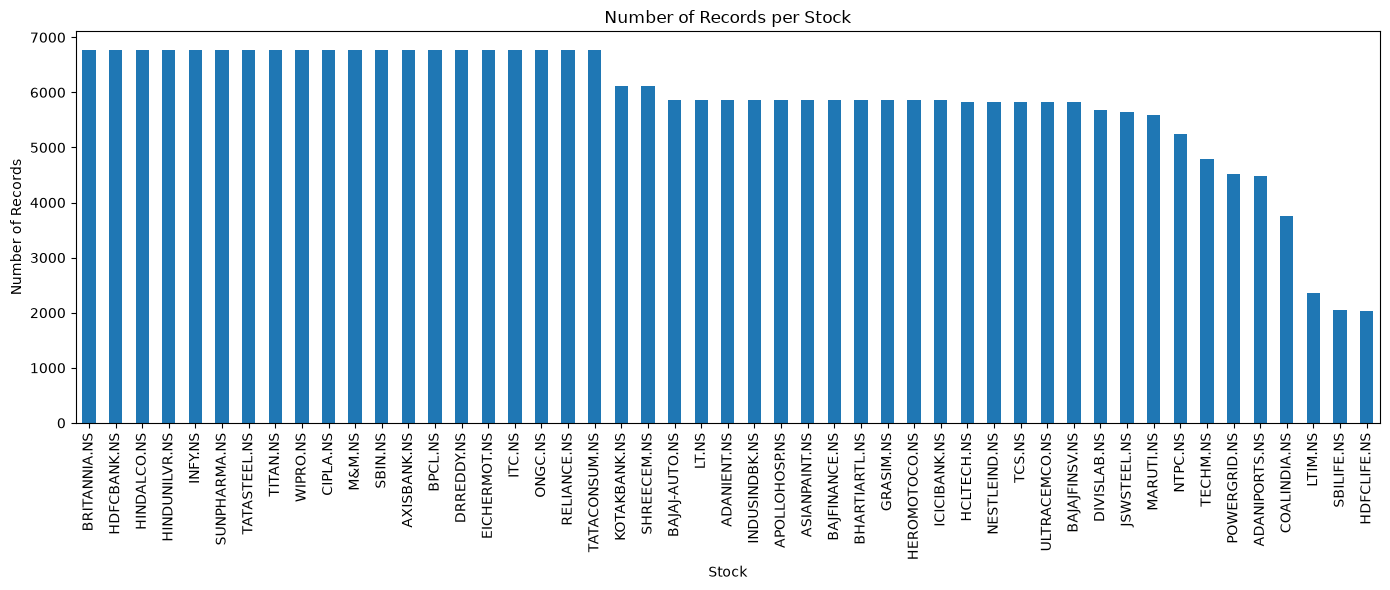

In [24]:
stock_counts = stock_df["Ticker"].value_counts()

plt.figure(figsize=(14, 6))

stock_counts.plot(kind="bar")

plt.title("Number of Records per Stock")
plt.xlabel("Stock")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [25]:
print("Stock duplicates:", stock_df.duplicated().sum())

Stock duplicates: 0


In [26]:
print("Sentiment duplicates:", sentiment_df.duplicated().sum())

Sentiment duplicates: 0


In [27]:
print("News duplicates:", news_df.duplicated().sum())

News duplicates: 974


In [28]:
missing = stock_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PEG_Ratio         287310
Stock_Split       287212
MA_200              9751
PE_Ratio            5857
Dividend_Yield      5857
Beta                3759
MA_50               2401
Volatility_20D       980
Daily_Return          49
dtype: int64


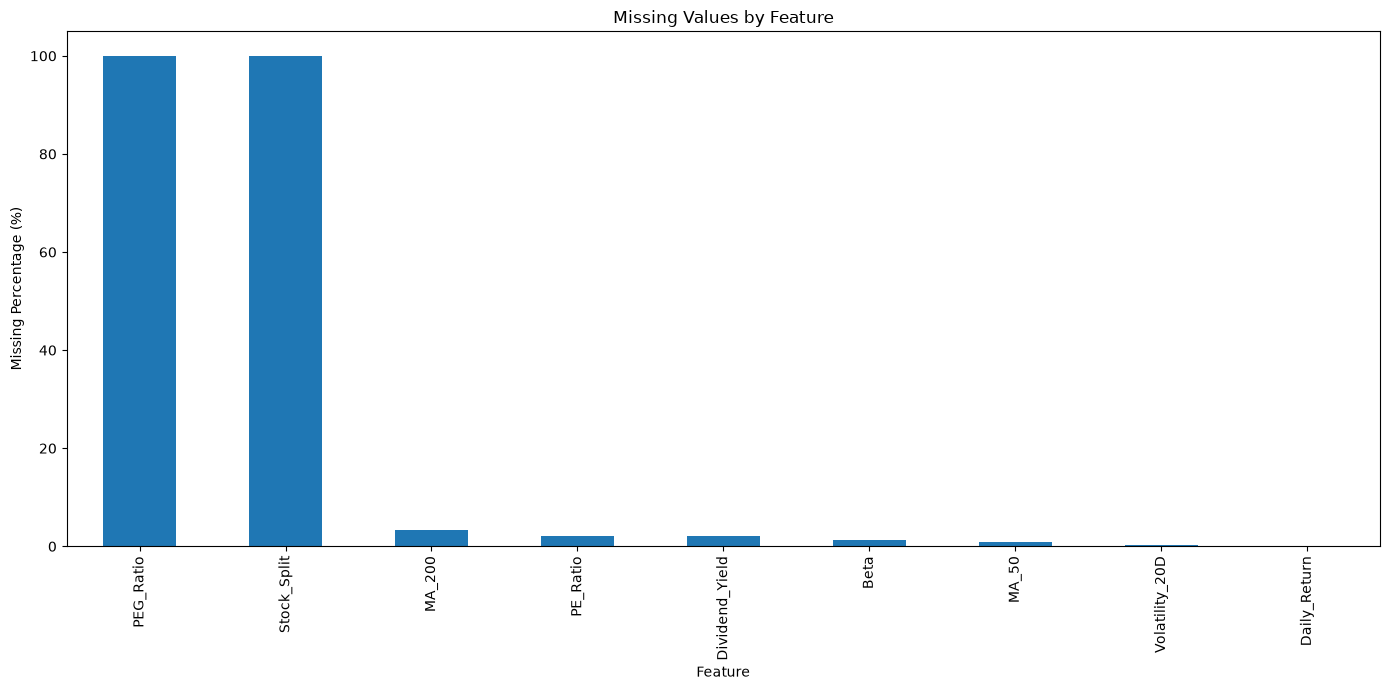

In [29]:
plt.figure(figsize=(14, 7))

missing_percent = (
    stock_df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[missing_percent > 0]

missing_percent.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [30]:
stock_df.describe()

,Open,High,Low,Close,Volume,Dividend,Stock_Split,Daily_Return,Volatility_20D,MA_50,MA_200,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
count,287310.000000,287310.000000,287310.000000,287310.000000,2.873100e+05,287310.000000,98.000000,287261.000000,286330.000000,284909.000000,277559.000000,2.873100e+05,281453.000000,287310.000000,0.0,287310.000000,281453.000000,287310.000000,283551.000000,287310.000000,287310.000000
mean,940.283620,951.740569,927.950491,939.614136,8.064757e+06,0.042278,3.265412,0.001943,0.024809,933.356778,914.202990,4.181424e+12,34.312064,27.133530,NaN,7.286666,1.638649,89.762003,0.318788,3642.977069,2583.723222
std,2457.975005,2486.870766,2426.231206,2455.886319,1.860599e+07,1.338670,2.670567,0.216306,0.215389,2439.073050,2385.386274,3.819222e+12,20.188516,14.965564,NaN,9.884414,1.782466,103.628972,0.229752,5440.636350,4079.800545
min,-0.012947,-0.012995,-0.012433,-0.012851,0.000000e+00,0.000000,0.043750,-5.676113,0.000000,-0.007684,0.031986,6.981300e+11,6.329224,7.200945,NaN,0.919242,0.050000,-26.230000,-0.109000,202.990000,125.300000
25%,70.237098,71.436894,68.887683,70.109819,6.296895e+05,0.000000,2.000000,-0.009882,0.013340,70.993137,73.516910,1.771073e+12,19.800245,17.381470,NaN,2.531458,0.500000,30.480000,0.175000,1082.500000,680.000000
50%,236.307412,239.866478,232.499912,236.094742,2.404242e+06,0.000000,2.000000,0.000000,0.017510,236.410760,235.432077,2.966612e+12,30.211220,22.947546,NaN,4.601731,0.980000,60.600000,0.259000,1752.500000,1281.700000
75%,816.242023,826.525145,805.341565,815.629150,8.013830e+06,0.000000,4.750000,0.011101,0.023770,811.248610,791.826212,4.587704e+12,44.247370,32.835144,NaN,7.842478,2.020000,93.640000,0.417000,4150.000000,2866.600000
max,32398.188356,32398.188356,31575.519038,32253.597656,8.552157e+08,210.000000,10.000000,108.493070,24.272505,30651.896523,29455.763115,1.888321e+13,85.461970,68.110050,NaN,57.940514,7.180000,477.630000,0.981000,32490.000000,25360.000000


In [31]:
stock_df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Volume",
        "Daily_Return",
        "Volatility_20D"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,287310.0,9.402836e+02,2.457975e+03,-0.012947,70.237098,2.363074e+02,8.162420e+02,3.239819e+04
High,287310.0,9.517406e+02,2.486871e+03,-0.012995,71.436894,2.398665e+02,8.265251e+02,3.239819e+04
Low,287310.0,9.279505e+02,2.426231e+03,-0.012433,68.887683,2.324999e+02,8.053416e+02,3.157552e+04
Close,287310.0,9.396141e+02,2.455886e+03,-0.012851,70.109819,2.360947e+02,8.156292e+02,3.225360e+04
Volume,287310.0,8.064757e+06,1.860599e+07,0.000000,629689.500000,2.404242e+06,8.013830e+06,8.552157e+08
Daily_Return,287261.0,1.942534e-03,2.163062e-01,-5.676113,-0.009882,0.000000e+00,1.110055e-02,1.084931e+02
Volatility_20D,286330.0,2.480897e-02,2.153893e-01,0.000000,0.013340,1.751050e-02,2.376955e-02,2.427251e+01


In [32]:
invalid_high = stock_df[
    (stock_df["High"] < stock_df["Open"]) |
    (stock_df["High"] < stock_df["Close"])
]

invalid_low = stock_df[
    (stock_df["Low"] > stock_df["Open"]) |
    (stock_df["Low"] > stock_df["Close"])
]

print("Invalid High records:", len(invalid_high))
print("Invalid Low records:", len(invalid_low))

Invalid High records: 123
Invalid Low records: 119


In [33]:
negative_volume = stock_df[stock_df["Volume"] < 0]

print("Negative volume records:", len(negative_volume))

Negative volume records: 0


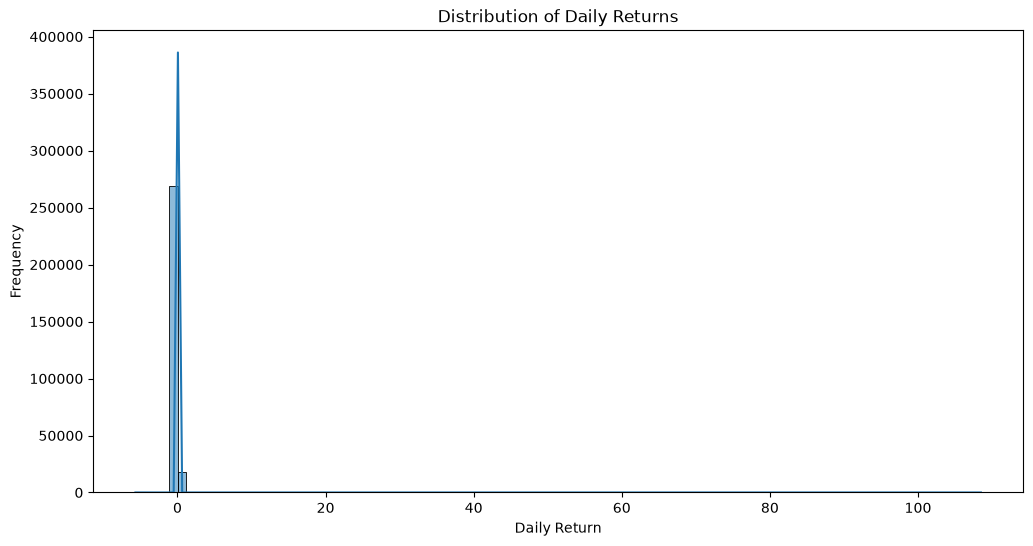

In [34]:
plt.figure(figsize=(12, 6))

sns.histplot(
    stock_df["Daily_Return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [35]:
stock_df[
    ["Ticker", "Date", "Close", "Daily_Return"]
].sort_values(
    "Daily_Return",
    ascending=False
).head(20)

,Ticker,Date,Close,Daily_Return
50802,BAJFINANCE.NS,2005-07-28 00:00:00+05:30,254.506653,108.493070
32995,CIPLA.NS,2003-11-27 00:00:00+05:30,81.885025,12.241736
37402,CIPLA.NS,2004-04-27 00:00:00+05:30,91.913361,11.907904
33856,CIPLA.NS,2003-12-26 00:00:00+05:30,88.080498,11.702659
26431,CIPLA.NS,2003-04-15 00:00:00+05:30,49.981861,11.543248
4657,TATASTEEL.NS,1999-11-23 00:00:00+05:30,38.639465,9.496085
857,TATASTEEL.NS,1999-03-02 00:00:00+05:30,31.355227,9.496081
4437,TATASTEEL.NS,1999-11-08 00:00:00+05:30,39.641266,9.496079
1237,TATASTEEL.NS,1999-03-29 00:00:00+05:30,26.774498,9.496079
1657,TATASTEEL.NS,1999-04-27 00:00:00+05:30,20.291824,9.496077


In [36]:
stock_df[
    ["Ticker", "Date", "Close", "Daily_Return"]
].sort_values(
    "Daily_Return"
).head(20)

,Ticker,Date,Close,Daily_Return
20376,ADANIENT.NS,2002-09-04 00:00:00+05:30,0.050103,-5.676113
50844,BAJFINANCE.NS,2005-07-29 00:00:00+05:30,2.326698,-0.990858
80825,BAJAJFINSV.NS,2008-05-26 00:00:00+05:30,48.575939,-0.926483
26405,CIPLA.NS,2003-04-14 00:00:00+05:30,3.984762,-0.920005
32954,CIPLA.NS,2003-11-26 00:00:00+05:30,6.183859,-0.920002
37375,CIPLA.NS,2004-04-26 00:00:00+05:30,7.120704,-0.919998
33815,CIPLA.NS,2003-12-25 00:00:00+05:30,6.934021,-0.919997
1257,TATASTEEL.NS,1999-03-30 00:00:00+05:30,2.450093,-0.908492
4457,TATASTEEL.NS,1999-11-09 00:00:00+05:30,3.752907,-0.905328
877,TATASTEEL.NS,1999-03-03 00:00:00+05:30,3.028162,-0.903424


In [37]:
ticker = stock_df["Ticker"].value_counts().index[0]

print("Selected stock:", ticker)

single_stock = stock_df[
    stock_df["Ticker"] == ticker
].sort_values("Date")

Selected stock: BRITANNIA.NS


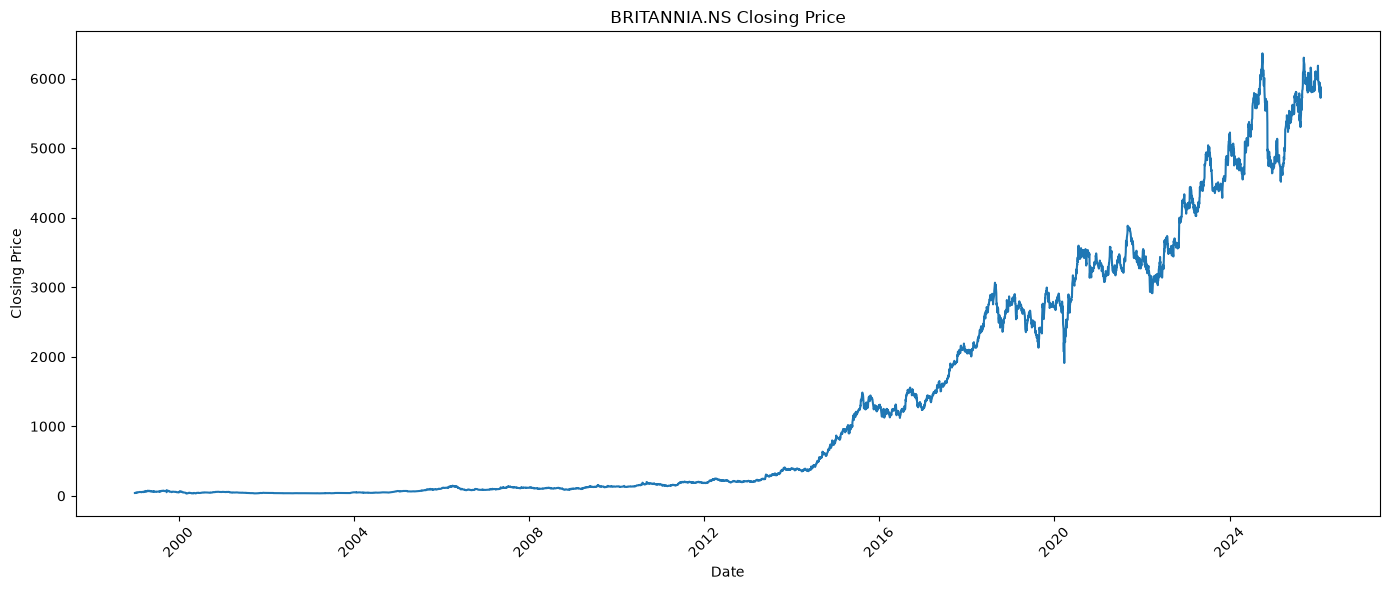

In [38]:
plt.figure(figsize=(14, 6))

plt.plot(
    single_stock["Date"],
    single_stock["Close"]
)

plt.title(f"{ticker} Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

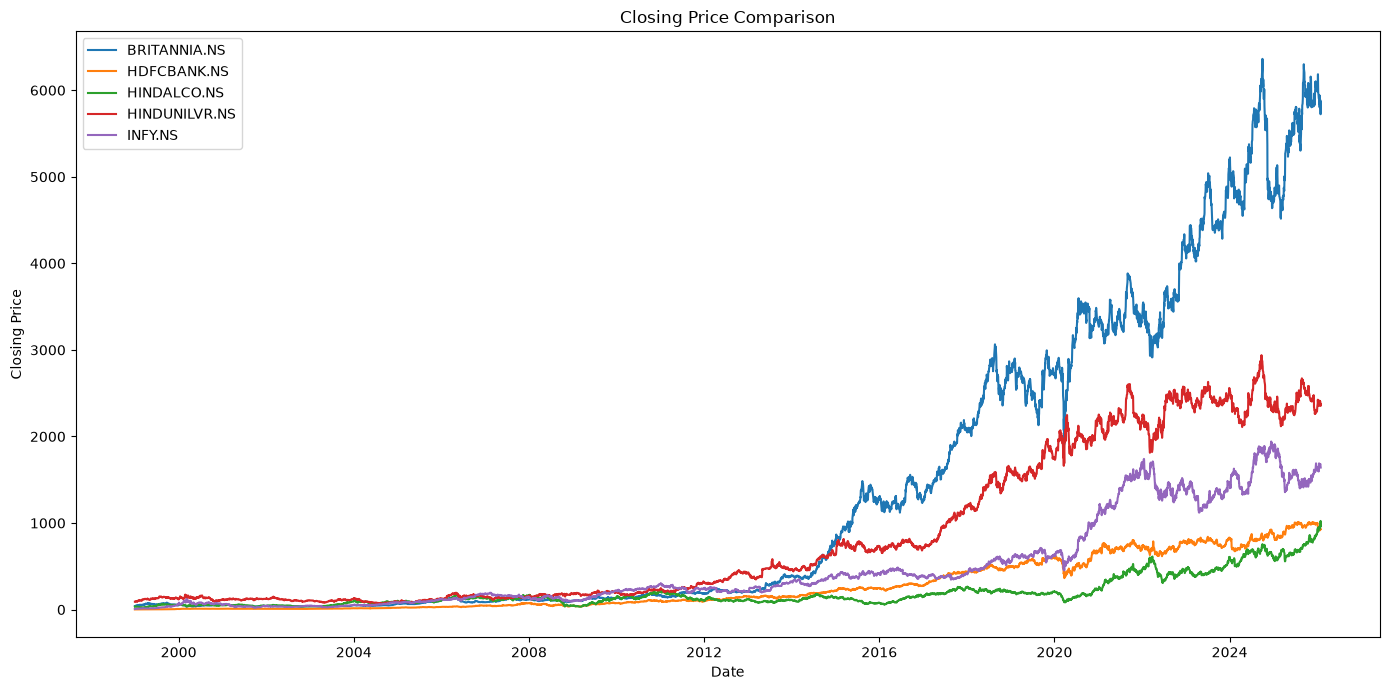

In [39]:
top_stocks = stock_df["Ticker"].value_counts().head(5).index

plt.figure(figsize=(14, 7))

for ticker in top_stocks:
    data = stock_df[stock_df["Ticker"] == ticker].sort_values("Date")

    plt.plot(
        data["Date"],
        data["Close"],
        label=ticker
    )

plt.title("Closing Price Comparison")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
normalized_df = stock_df.sort_values(
    ["Ticker", "Date"]
).copy()

normalized_df["Normalized_Close"] = (
    normalized_df["Close"] /
    normalized_df.groupby("Ticker")["Close"].transform("first")
)

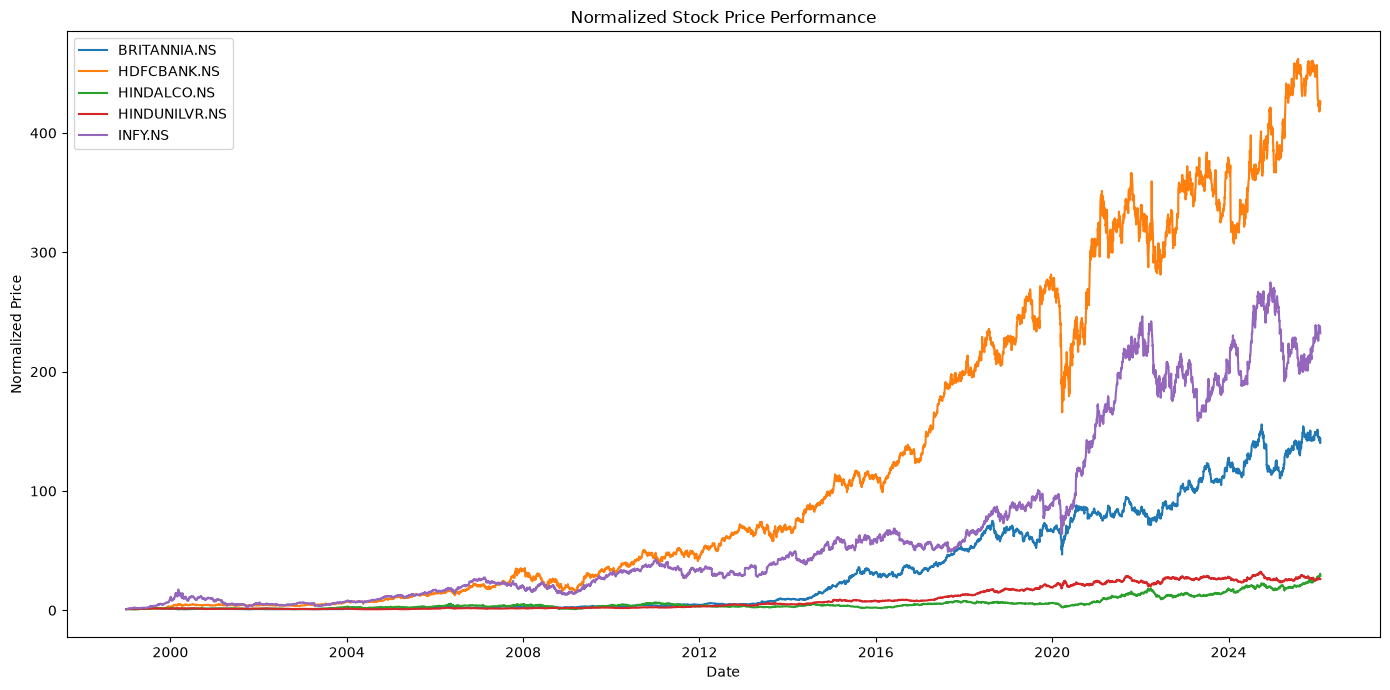

In [41]:
plt.figure(figsize=(14, 7))

for ticker in top_stocks:
    data = normalized_df[
        normalized_df["Ticker"] == ticker
    ]

    plt.plot(
        data["Date"],
        data["Normalized_Close"],
        label=ticker
    )

plt.title("Normalized Stock Price Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
numeric_cols = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "Volatility_20D",
    "MA_50",
    "MA_200",
    "Market_Cap",
    "PE_Ratio",
    "Forward_PE",
    "Price_to_Book",
    "Dividend_Yield",
    "EPS",
    "Beta"
]

In [43]:
corr = stock_df[numeric_cols].corr()

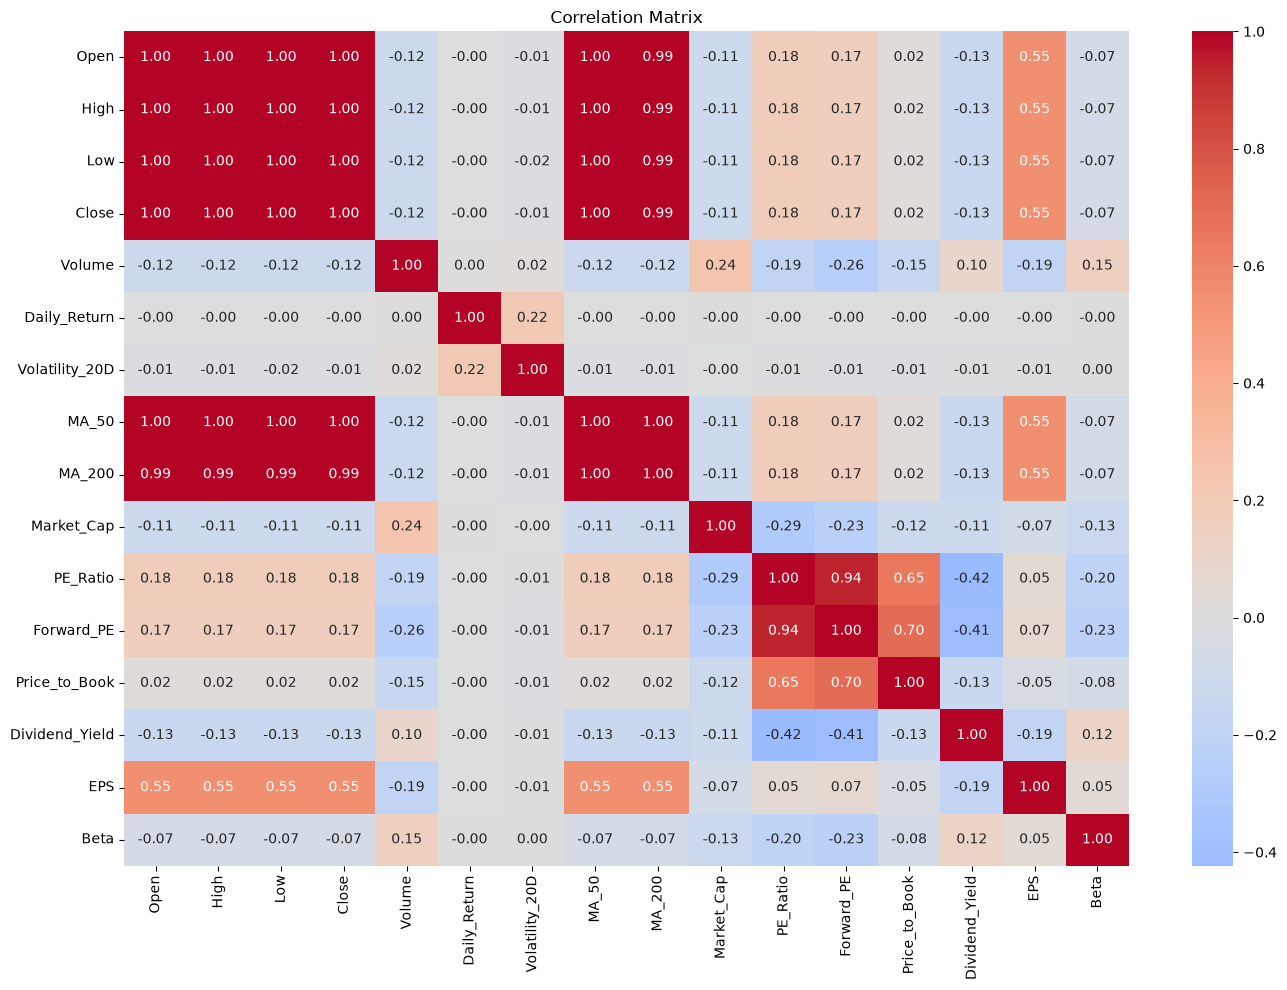

In [44]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [45]:
sentiment_df.describe()

,Date,News_Count,Avg_Sentiment,Positive_Sentiment,Negative_Sentiment,Neutral_Sentiment,Max_Sentiment,Min_Sentiment,Sentiment_Std
count,3507,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000,3507.000000
mean,2016-12-05 04:37:09.597947,5.453949,-0.059053,0.172527,0.231581,0.595892,0.318455,-0.443182,0.323651
min,2008-01-02 00:00:00,1.000000,-0.965842,0.006700,0.008421,0.011675,-0.965842,-0.968342,0.000000
25%,2013-05-16 12:00:00,2.000000,-0.212409,0.054720,0.053398,0.445269,0.035494,-0.919865,0.068723
50%,2017-01-05 00:00:00,4.000000,-0.016827,0.118006,0.181851,0.609257,0.193067,-0.448588,0.358505
75%,2020-08-24 12:00:00,6.000000,0.088437,0.249635,0.343511,0.795494,0.758278,-0.022880,0.512049
max,2024-03-04 00:00:00,55.000000,0.926617,0.950584,0.975366,0.948111,0.937908,0.926617,1.242276
std,NaN,5.573481,0.288364,0.155415,0.209794,0.230609,0.427165,0.443554,0.245756


In [46]:
sentiment_df.isnull().sum()

Date                  0
News_Count            0
Avg_Sentiment         0
Positive_Sentiment    0
Negative_Sentiment    0
Neutral_Sentiment     0
Max_Sentiment         0
Min_Sentiment         0
Sentiment_Std         0
dtype: int64

In [47]:
sentiment_df["Date"].min(), sentiment_df["Date"].max()

(Timestamp('2008-01-02 00:00:00'), Timestamp('2024-03-04 00:00:00'))

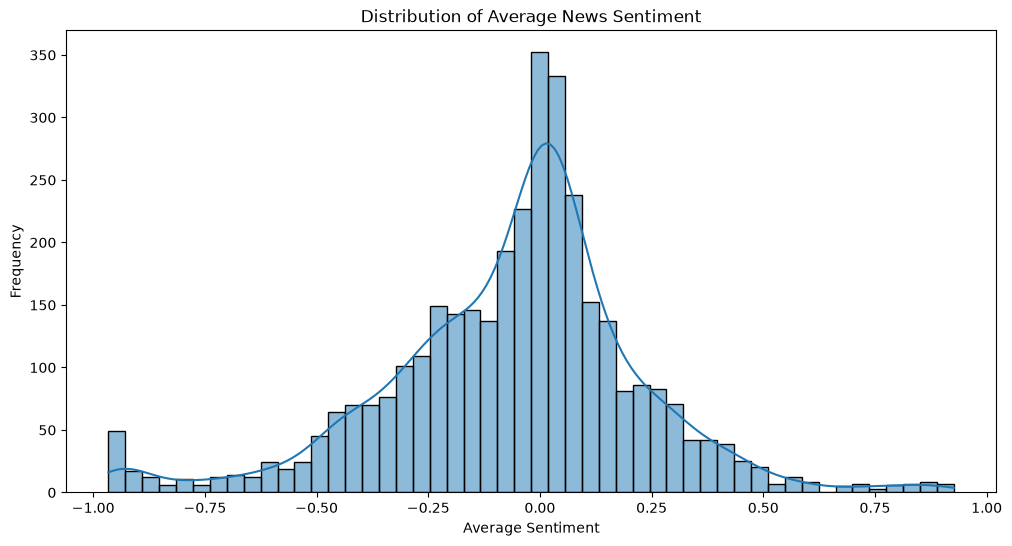

In [48]:
plt.figure(figsize=(12, 6))

sns.histplot(
    sentiment_df["Avg_Sentiment"],
    bins=50,
    kde=True
)

plt.title("Distribution of Average News Sentiment")
plt.xlabel("Average Sentiment")
plt.ylabel("Frequency")

plt.show()

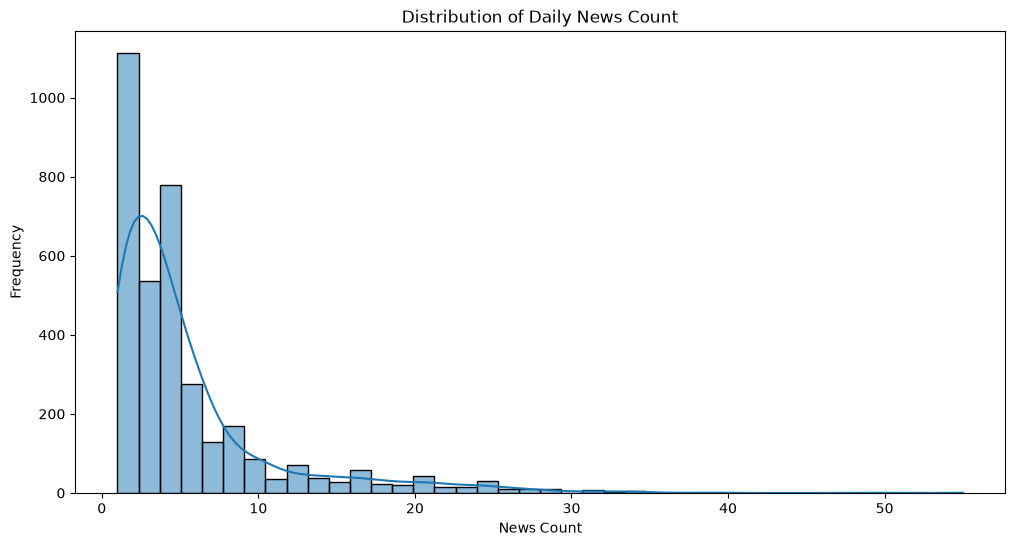

In [49]:
plt.figure(figsize=(12, 6))

sns.histplot(
    sentiment_df["News_Count"],
    bins=40,
    kde=True
)

plt.title("Distribution of Daily News Count")
plt.xlabel("News Count")
plt.ylabel("Frequency")

plt.show()

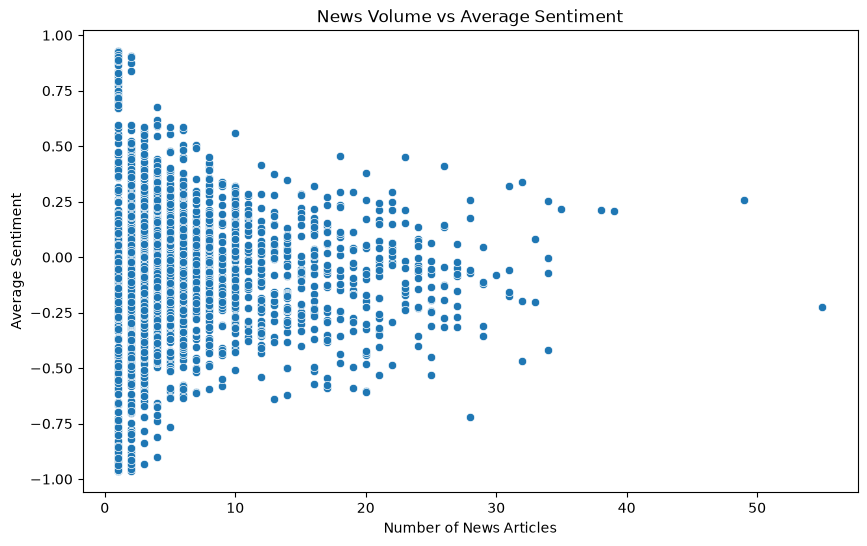

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sentiment_df,
    x="News_Count",
    y="Avg_Sentiment"
)

plt.title("News Volume vs Average Sentiment")
plt.xlabel("Number of News Articles")
plt.ylabel("Average Sentiment")

plt.show()

In [51]:
news_df.head(10)

,Title,Date,CP
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16
2,2008 predictions for the S&P 500,2008-01-02,1447.16
3,"U.S. Stocks Higher After Economic Data, Monsan...",2008-01-03,1447.16
4,U.S. Stocks Climb As Hopes Increase For More F...,2008-01-07,1416.18
5,How Investing in Intangibles -- Like Employee ...,2008-01-09,1409.13
6,Head And Shoulders Top Bodes Ill For Bulls,2008-01-09,1409.13
7,U.S. Stocks Zigzag Higher As Bernanke Speech S...,2008-01-10,1420.33
8,It's a Black Monday as stock markets tank in e...,2008-01-22,1310.50
9,U.S. Stocks Largely Recover From Early Plunge,2008-01-22,1310.50


In [52]:
print("Number of news articles:", len(news_df))
print("Unique dates:", news_df["Date"].nunique())

Number of news articles: 19127
Unique dates: 3507


In [53]:
print(
    "Duplicate news titles:",
    news_df["Title"].duplicated().sum()
)

Duplicate news titles: 1073


In [54]:
news_df["Title"].str.len().describe()

count    19127.000000
mean        60.291421
std         19.517099
min          6.000000
25%         46.000000
50%         58.000000
75%         71.000000
max        172.000000
Name: Title, dtype: float64

In [55]:
summary_df.head()

,Ticker,Company_Name,Sector,First_Date,Last_Date,Total_Trading_Days,Starting_Price,Ending_Price,Total_Return_%,Highest_Price,Lowest_Price,Avg_Daily_Volume,Total_Dividends_Paid,Number_of_Splits,Avg_Daily_Return_%,Volatility_%,Current_Market_Cap,Current_PE_Ratio
0,EICHERMOT.NS,Eicher Motors Ltd.,Automobile,1999-01-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,6767,0.712911,7122.500000,998972.801823,7613.500000,0.584353,5.260628e+05,271.600000,1,0.293300,11.334566,1953696317440,38.377605
1,BAJFINANCE.NS,Bajaj Finance Ltd.,Financials,2002-07-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,5856,0.392581,929.849976,236755.581063,1102.500000,0.266442,9.562993e+06,18.844086,2,2.002004,141.815279,5780268908544,31.541723
2,TITAN.NS,Titan Company Ltd.,Consumer Durables,1999-01-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,6770,3.933924,3977.399902,101005.148498,4312.100098,1.210438,3.647869e+06,72.700000,1,0.139343,2.741165,3528133705728,85.461970
3,SHREECEM.NS,Shree Cement Ltd.,Cement,2001-07-02 00:00:00+05:30,2026-01-30 00:00:00+05:30,6116,27.222359,26985.000000,99028.074440,32398.188356,18.588853,2.836315e+04,1081.500000,0,0.138320,2.263643,973638991872,56.497707
4,SUNPHARMA.NS,Sun Pharmaceutical Industries Ltd.,Pharma,1999-01-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,6770,1.718485,1595.300049,92731.744721,1942.212840,1.703690,3.132031e+06,89.000000,5,0.125672,2.227590,3827659177984,36.631460


In [56]:
summary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Ticker                49 non-null     str    
 1   Company_Name          49 non-null     str    
 2   Sector                49 non-null     str    
 3   First_Date            49 non-null     str    
 4   Last_Date             49 non-null     str    
 5   Total_Trading_Days    49 non-null     int64  
 6   Starting_Price        49 non-null     float64
 7   Ending_Price          49 non-null     float64
 8   Total_Return_%        49 non-null     float64
 9   Highest_Price         49 non-null     float64
 10  Lowest_Price          49 non-null     float64
 11  Avg_Daily_Volume      49 non-null     float64
 12  Total_Dividends_Paid  49 non-null     float64
 13  Number_of_Splits      49 non-null     int64  
 14  Avg_Daily_Return_%    49 non-null     float64
 15  Volatility_%          49 non-null   

In [57]:
summary_df.describe(include="all")

,Ticker,Company_Name,Sector,First_Date,Last_Date,Total_Trading_Days,Starting_Price,Ending_Price,Total_Return_%,Highest_Price,Lowest_Price,Avg_Daily_Volume,Total_Dividends_Paid,Number_of_Splits,Avg_Daily_Return_%,Volatility_%,Current_Market_Cap,Current_PE_Ratio
count,49,49,49,49,49,49.000000,49.000000,49.000000,4.900000e+01,49.000000,49.000000,4.900000e+01,49.000000,49.000000,49.000000,49.000000,4.900000e+01,48.000000
unique,49,49,13,15,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,EICHERMOT.NS,Eicher Motors Ltd.,Financials,1999-01-01 00:00:00+05:30,2026-01-30 00:00:00+05:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,10,20,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,5863.469388,84.965499,3228.890612,-2.956497e+05,3818.105233,50.910163,7.524116e+06,247.898301,2.000000,0.186169,7.173586,4.023024e+12,35.544584
std,NaN,NaN,NaN,NaN,NaN,1188.986230,157.243504,4656.837740,2.381795e+06,5499.687549,109.259145,1.129254e+07,342.385395,1.825742,0.313371,20.470705,3.716943e+12,21.335541
min,NaN,NaN,NaN,NaN,NaN,2027.000000,-0.012173,193.130005,-1.659749e+07,202.990005,-0.012433,2.836315e+04,2.763500,0.000000,0.038636,1.560890,6.981300e+11,6.329224
25%,NaN,NaN,NaN,NaN,NaN,5826.000000,6.354040,929.849976,2.781095e+03,1082.500000,3.984762,1.060249e+06,59.825000,1.000000,0.087257,1.992824,1.771073e+12,20.510175
50%,NaN,NaN,NaN,NaN,NaN,5858.000000,19.426748,1595.300049,7.433580e+03,1924.546608,9.917574,3.562630e+06,102.750000,1.000000,0.109107,2.319354,2.716223e+12,30.721866
75%,NaN,NaN,NaN,NaN,NaN,6767.000000,80.955704,3431.800049,1.526916e+04,4195.000000,35.531099,9.552673e+06,309.108887,3.000000,0.138320,3.554906,4.257979e+12,45.358523


In [58]:
summary_df["Ticker"].nunique()

49

In [59]:
stock_target_df = stock_df.sort_values(
    ["Ticker", "Date"]
).copy()

stock_target_df["Next_Close"] = (
    stock_target_df
    .groupby("Ticker")["Close"]
    .shift(-1)
)

stock_target_df["Target"] = (
    stock_target_df["Next_Close"] >
    stock_target_df["Close"]
).astype(int)

In [60]:
stock_target_df[
    [
        "Ticker",
        "Date",
        "Close",
        "Next_Close",
        "Target"
    ]
].head(20)

,Ticker,Date,Close,Next_Close,Target
18740,ADANIENT.NS,2002-07-01 00:00:00+05:30,-0.012173,-0.012269,0
18773,ADANIENT.NS,2002-07-02 00:00:00+05:30,-0.012269,-0.012269,0
18806,ADANIENT.NS,2002-07-03 00:00:00+05:30,-0.012269,-0.012337,0
18839,ADANIENT.NS,2002-07-04 00:00:00+05:30,-0.012337,-0.012310,1
18872,ADANIENT.NS,2002-07-05 00:00:00+05:30,-0.012310,-0.012851,0
18905,ADANIENT.NS,2002-07-08 00:00:00+05:30,-0.012851,-0.012515,1
18938,ADANIENT.NS,2002-07-09 00:00:00+05:30,-0.012515,-0.012502,1
18971,ADANIENT.NS,2002-07-10 00:00:00+05:30,-0.012502,-0.012296,1
19004,ADANIENT.NS,2002-07-11 00:00:00+05:30,-0.012296,-0.012392,0
19037,ADANIENT.NS,2002-07-12 00:00:00+05:30,-0.012392,-0.012139,1


In [61]:
print(
    stock_target_df["Target"]
    .value_counts()
)

Target
0    143807
1    143503
Name: count, dtype: int64


In [62]:
print(
    stock_target_df["Target"]
    .value_counts(normalize=True) * 100
)

Target
0    50.052905
1    49.947095
Name: proportion, dtype: float64


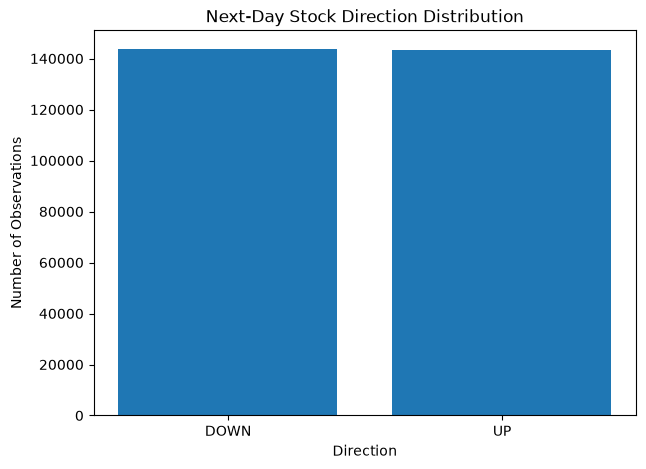

In [63]:
target_counts = stock_target_df["Target"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["DOWN", "UP"],
    [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
)

plt.title("Next-Day Stock Direction Distribution")
plt.xlabel("Direction")
plt.ylabel("Number of Observations")

plt.show()

# Day 1 Findings

## Dataset

The project contains historical data for 49 Indian stocks.

The stock dataset contains approximately 287K observations
covering 1999 to January 2026.

The sentiment and news datasets cover approximately 2008
to March 2024.

## Important Findings

1. The stock dataset contains 49 unique stocks.
2. There are no exact duplicate stock records.
3. Several fundamental and technical features contain missing values.
4. PEG_Ratio has a very high percentage of missing values.
5. News and sentiment data have a shorter historical period than stock data.
6. The next-day UP/DOWN target is approximately balanced.
7. Stock prices and technical indicators show expected correlations.
8. Extreme daily returns require investigation before modeling.

## Modeling Implications

The final model must use chronological train/test splitting.

Random shuffling must be avoided because it can introduce
future information into the training data.

News sentiment will only be used when information is available
before the prediction cutoff.

In [70]:
sample_df = (
    stock_df
    .groupby("Ticker", sort=False)
    .sample(
        n=100,
        random_state=42
    )
    .reset_index(drop=True)
)

# Sort the sample chronologically by stock and date
sample_df = sample_df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

print("Original dataset:", stock_df.shape)
print("Sample dataset:", sample_df.shape)



Original dataset: (287310, 25)
Sample dataset: (4900, 25)


In [71]:
print("Original dataset:", stock_df.shape)
print("Sample dataset:", sample_df.shape)

Original dataset: (287310, 25)
Sample dataset: (4900, 25)


In [72]:
print(
    sample_df["Ticker"].nunique()
)

49


In [73]:
print(
    sample_df["Ticker"].value_counts()
)

Ticker
ADANIENT.NS      100
ADANIPORTS.NS    100
APOLLOHOSP.NS    100
ASIANPAINT.NS    100
AXISBANK.NS      100
BAJAJ-AUTO.NS    100
BAJAJFINSV.NS    100
BAJFINANCE.NS    100
BHARTIARTL.NS    100
BPCL.NS          100
BRITANNIA.NS     100
CIPLA.NS         100
COALINDIA.NS     100
DIVISLAB.NS      100
DRREDDY.NS       100
EICHERMOT.NS     100
GRASIM.NS        100
HCLTECH.NS       100
HDFCBANK.NS      100
HDFCLIFE.NS      100
HEROMOTOCO.NS    100
HINDALCO.NS      100
HINDUNILVR.NS    100
ICICIBANK.NS     100
INDUSINDBK.NS    100
INFY.NS          100
ITC.NS           100
JSWSTEEL.NS      100
KOTAKBANK.NS     100
LT.NS            100
LTIM.NS          100
M&M.NS           100
MARUTI.NS        100
NESTLEIND.NS     100
NTPC.NS          100
ONGC.NS          100
POWERGRID.NS     100
RELIANCE.NS      100
SBILIFE.NS       100
SBIN.NS          100
SHREECEM.NS      100
SUNPHARMA.NS     100
TATACONSUM.NS    100
TATASTEEL.NS     100
TCS.NS           100
TECHM.NS         100
TITAN.NS         100
ULTRAC

In [74]:
sample_df = sample_df.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)

In [75]:
sample_df.head()

,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,Stock_Split,Daily_Return,Volatility_20D,MA_50,MA_200,Market_Cap,PE_Ratio,Forward_PE,PEG_Ratio,Price_to_Book,Dividend_Yield,EPS,Beta,52Week_High,52Week_Low
0,2002-08-15 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,-0.010749,-0.010749,-0.010749,-0.010749,0,0.0,NaN,0.000000,0.013458,NaN,NaN,2611735429120,31.154974,45.89732,NaN,4.53401,0.06,64.85,0.491,2695.0,1848.0
1,2002-09-25 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.045818,0.047687,0.045818,0.046817,528109,0.0,NaN,-0.011564,1.268512,0.008199,NaN,2611735429120,31.154974,45.89732,NaN,4.53401,0.06,64.85,0.491,2695.0,1848.0
2,2002-11-29 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.048331,0.050876,0.048331,0.049878,477885,0.0,NaN,-0.000646,0.015360,0.046696,NaN,2611735429120,31.154974,45.89732,NaN,4.53401,0.06,64.85,0.491,2695.0,1848.0
3,2003-02-03 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.042241,0.043466,0.042209,0.043079,468725,0.0,NaN,0.007535,0.012526,0.046819,NaN,2611735429120,31.154974,45.89732,NaN,4.53401,0.06,64.85,0.491,2695.0,1848.0
4,2003-08-19 00:00:00+05:30,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.062218,0.063636,0.061735,0.062057,485519,0.0,NaN,-0.023327,0.017042,0.060500,0.048933,2611735429120,31.154974,45.89732,NaN,4.53401,0.06,64.85,0.491,2695.0,1848.0


In [76]:
sample_path = "../data/sample/sample_stock_data.csv"

sample_df.to_csv(
    sample_path,
    index=False
)

print("Sample saved successfully!")

Sample saved successfully!


In [77]:
import os

print(
    os.path.exists(sample_path)
)

True


In [78]:
file_size = os.path.getsize(sample_path)

print(
    f"File size: {file_size / 1024:.2f} KB"
)

File size: 1445.71 KB


In [79]:
sentiment_sample = sentiment_df.sample(
    n=min(1000, len(sentiment_df)),
    random_state=42
)

In [80]:
sentiment_sample = sentiment_sample.sort_values(
    "Date"
)

In [81]:
sentiment_sample.to_csv(
    "../data/sample/sample_sentiment_data.csv",
    index=False
)

In [83]:
news_sample = news_df.sample(
    n=min(2000, len(news_df)),
    random_state=42
)

In [84]:
news_sample = news_sample.sort_values(
    "Date"
)

In [85]:
news_sample.to_csv(
    "../data/sample/sample_news_data.csv",
    index=False
)

In [87]:

summary_df.to_csv(
    "../data/sample/sample_company_summary.csv",
    index=False
)